# OBJECTIVE

The aim of this exercise is to engineer features from the results of the statistical tests (Spearman's correlation, Kruskal-Wallis and Mann-Whitney) to train the machine learning model to predict outcomes (Is_winner's 0 or 1) and combination of moves that leads to those outcomes.

In [1]:
# STEP 1 — Setup: imports and dataset loading
# This cell prepares all libraries and reads the cleaned dataset used by later steps.

# Import libraries and cleaned dataset for feature engineering
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

# Load the cleaned dataset using a robust path
candidate_paths = [
    Path('data file/Clean_Data/ludo_dataset_cleaned.csv'),
    Path('../data file/Clean_Data/ludo_dataset_cleaned.csv'),
    Path('data file/Raw_Data/ludo_dataset_cleaned.csv'),
    Path('../data file/Raw_Data/ludo_dataset_cleaned.csv'),
]

dataset_path = next((path for path in candidate_paths if path.exists()), None)
if dataset_path is None:
    raise FileNotFoundError('Could not find ludo_dataset_cleaned.csv in expected locations.')

# Read dataset into memory
df = pd.read_csv(dataset_path)
df.head(20)

,Game_ID,Turn,Player,Dice_Roll,Token_Moved,Position_Before,Position_After,Tokens_Home,Tokens_Active,Tokens_Finished,Captured_Opponent,Is_Winner
0,0,1,Red,6,1,0.0,1.0,3,1,0,0,0
1,0,2,Red,1,1,1.0,2.0,3,1,0,0,0
2,0,3,Green,6,3,0.0,1.0,3,1,0,0,0
3,0,4,Green,2,3,1.0,3.0,3,1,0,0,0
4,0,7,Red,6,1,2.0,8.0,3,1,0,0,0
5,0,8,Red,6,1,8.0,14.0,3,1,0,0,0
6,0,9,Red,5,1,14.0,19.0,3,1,0,0,0
7,0,10,Green,4,3,3.0,7.0,3,1,0,0,0
8,0,13,Red,1,1,19.0,20.0,3,1,0,0,0
9,0,14,Green,2,3,7.0,9.0,3,1,0,0,0


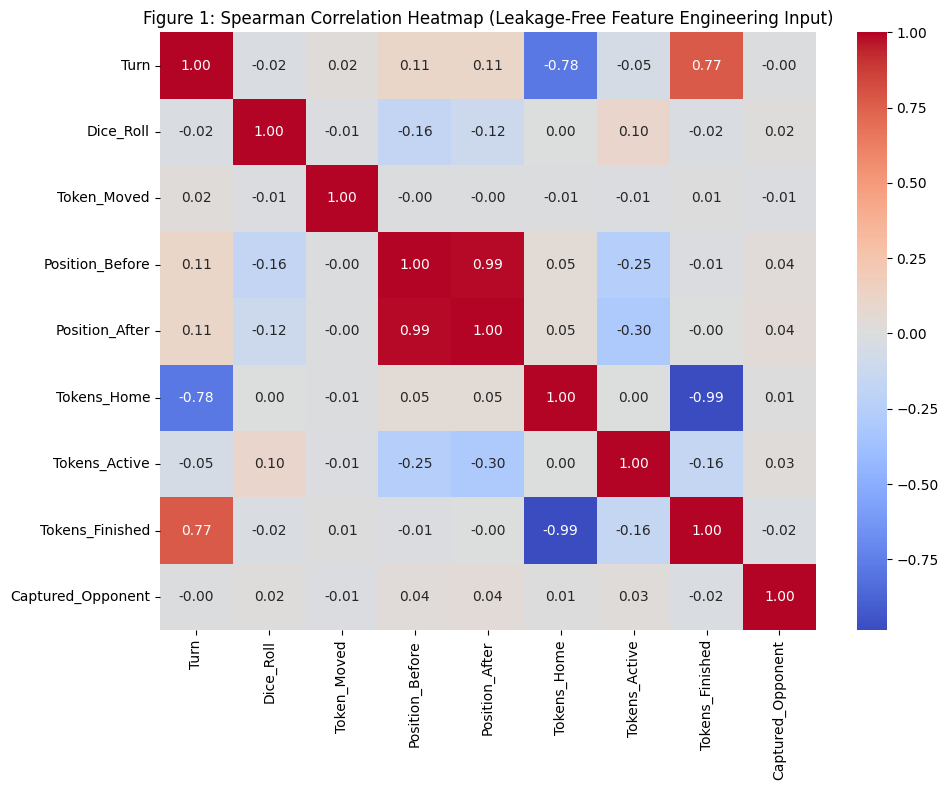

Imported Spearman correlation context from: Ludo_EDA.ipynb
Excluded columns from feature engineering: ['Is_Winner', 'Game_ID']


,feature_1,feature_2,spearman_rho,abs_rho,strength,direction
0,Position_Before,Position_After,0.987347,0.987347,Strong,Positive
1,Tokens_Home,Tokens_Finished,-0.985741,0.985741,Strong,Negative
2,Turn,Tokens_Home,-0.777921,0.777921,Strong,Negative
3,Turn,Tokens_Finished,0.774726,0.774726,Strong,Positive
4,Position_After,Tokens_Active,-0.298541,0.298541,Weak,Negative
5,Position_Before,Tokens_Active,-0.250533,0.250533,Weak,Negative
6,Dice_Roll,Position_Before,-0.164264,0.164264,Weak,Negative
7,Tokens_Active,Tokens_Finished,-0.161512,0.161512,Weak,Negative
8,Dice_Roll,Position_After,-0.115641,0.115641,Weak,Negative
9,Turn,Tokens_Active,-0.050348,0.050348,Weak,Negative


In [2]:
# STEP 2 — Correlation analysis input for feature engineering
# This cell builds a leakage-free Spearman correlation context and a filtered pair table.

# Spearman heatmap + categorized pairwise-correlation results
import json

# Optional validation: confirm Ludo_EDA contains the Spearman-correlation step
eda_notebook_candidates = [
    Path('jupyter_notebooks/Ludo_EDA.ipynb'),
    Path('Ludo_EDA.ipynb'),
    Path('../jupyter_notebooks/Ludo_EDA.ipynb'),
]
eda_notebook_path = next((p for p in eda_notebook_candidates if p.exists()), None)
if eda_notebook_path is None:
    raise FileNotFoundError('Could not find Ludo_EDA.ipynb in expected locations.')

with open(eda_notebook_path, 'r', encoding='utf-8') as f:
    eda_nb = json.load(f)

correlation_step_found = any(
    c.get('cell_type') == 'code' and
    "correlation_matrix = df_num.corr(method='spearman')" in ''.join(c.get('source', []))
    for c in eda_nb.get('cells', [])
)
if not correlation_step_found:
    raise ValueError('Spearman correlation step not found in Ludo_EDA.ipynb.')

# Compute Spearman correlation matrix without target and identifier columns to avoid leakage
excluded_for_engineering = ['Is_Winner', 'Game_ID']
df_num = df.select_dtypes(include=np.number).drop(columns=excluded_for_engineering, errors='ignore').copy()
correlation_matrix = df_num.corr(method='spearman')

# 1) Heatmap for quick relationship inspection
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Figure 1: Spearman Correlation Heatmap (Leakage-Free Feature Engineering Input)')
plt.tight_layout()
plt.show()

# 2) Categorized pairwise-correlation table
def classify_corr(rho):
    abs_rho = abs(rho)
    if abs_rho >= 0.7:
        strength = 'Strong'
    elif abs_rho >= 0.3:
        strength = 'Moderate'
    else:
        strength = 'Weak'

    direction = 'Positive' if rho > 0 else ('Negative' if rho < 0 else 'Neutral')
    return strength, direction

# Build pair list from upper triangle of correlation matrix
pairs = []
cols = correlation_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        f1, f2 = cols[i], cols[j]
        rho = float(correlation_matrix.loc[f1, f2])
        strength, direction = classify_corr(rho)

        # Keep only requested categories (strong/moderate or any negative)
        keep = (strength in {'Strong', 'Moderate'}) or (direction == 'Negative')
        if keep:
            pairs.append({
                'feature_1': f1,
                'feature_2': f2,
                'spearman_rho': rho,
                'abs_rho': abs(rho),
                'strength': strength,
                'direction': direction,
            })

pairwise_correlation_results = (
    pd.DataFrame(pairs)
    .sort_values(['abs_rho', 'direction'], ascending=[False, True])
    .reset_index(drop=True)
)

print(f"Imported Spearman correlation context from: {eda_notebook_path}")
print(f"Excluded columns from feature engineering: {excluded_for_engineering}")
display(pairwise_correlation_results)

In [3]:
# STEP 3 — Feature engineering from correlation categories
# This cell creates engineered columns, applies uniform naming, and previews resulting features.

# Engineer features by correlation type, then drop source features used in engineering (except identifiers/target)
eps = 1e-6  # protects against division by zero
excluded_for_engineering = {'Is_Winner', 'Game_ID'}

# Rebuild pairwise table if it does not exist in memory
if 'pairwise_correlation_results' not in globals():
    pairs = []
    cols = correlation_matrix.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            f1, f2 = cols[i], cols[j]
            if f1 in excluded_for_engineering or f2 in excluded_for_engineering:
                continue
            rho = float(correlation_matrix.loc[f1, f2])
            abs_rho = abs(rho)
            if abs_rho >= 0.7:
                strength = 'Strong'
            elif abs_rho >= 0.3:
                strength = 'Moderate'
            else:
                strength = 'Weak'
            direction = 'Positive' if rho > 0 else ('Negative' if rho < 0 else 'Neutral')
            pairs.append({
                'feature_1': f1,
                'feature_2': f2,
                'spearman_rho': rho,
                'abs_rho': abs_rho,
                'strength': strength,
                'direction': direction,
            })
    pairwise_correlation_results = pd.DataFrame(pairs)

# Ensure no target/identifier-based pairs are used
pairwise_correlation_results = pairwise_correlation_results.loc[
    ~pairwise_correlation_results['feature_1'].isin(excluded_for_engineering)
    & ~pairwise_correlation_results['feature_2'].isin(excluded_for_engineering)
].reset_index(drop=True)

# Helper: normalize raw feature names for consistent engineered column naming
def normalize_feature_name(name):
    return ''.join(ch if ch.isalnum() else '_' for ch in str(name)).strip('_').lower()

# Helper: unified naming convention for engineered columns
def engineered_col_name(f1, f2, transform_tag):
    return f"eng_{transform_tag}__{normalize_feature_name(f1)}__{normalize_feature_name(f2)}"

# Start from clean copy of base data
df_fe = df.copy()

created_strong_pos = []
created_strong_neg = []
created_weak_neg = []

pending_columns = {}
source_features_used = set()

# Create engineered features by correlation category
for _, row in pairwise_correlation_results.iterrows():
    f1 = row['feature_1']
    f2 = row['feature_2']
    strength = row['strength']
    direction = row['direction']

    if strength == 'Strong' and direction == 'Positive':
        new_col = engineered_col_name(f1, f2, 'strong_pos_div')
        source_features_used.update([f1, f2])
        pending_columns[new_col] = df_fe[f1] / (df_fe[f2] + eps)
        created_strong_pos.append(new_col)

    elif strength == 'Strong' and direction == 'Negative':
        new_col = engineered_col_name(f1, f2, 'strong_neg_mul')
        source_features_used.update([f1, f2])
        pending_columns[new_col] = df_fe[f1] * df_fe[f2]
        created_strong_neg.append(new_col)

    elif strength == 'Weak' and direction == 'Negative':
        new_col = engineered_col_name(f1, f2, 'weak_neg_combo')
        source_features_used.update([f1, f2])
        ratio = df_fe[f1] / (df_fe[f2] + eps)
        safe_sqrt_term = np.sqrt(np.abs(ratio))
        pending_columns[new_col] = (df_fe[f1] * df_fe[f2]) - (safe_sqrt_term + ratio)
        created_weak_neg.append(new_col)

# Append engineered features to dataframe
if pending_columns:
    df_fe = pd.concat([df_fe, pd.DataFrame(pending_columns, index=df_fe.index)], axis=1).copy()

# Drop source columns used to create engineered columns (except protected ones)
protected_columns = {'Game_ID', 'Is_Winner'}
drop_source_columns = sorted([
    col for col in source_features_used
    if col in df_fe.columns and col not in protected_columns
])
if drop_source_columns:
    df_fe = df_fe.drop(columns=drop_source_columns).copy()

# Progress summary
print(f"Strong positive features created: {len(created_strong_pos)}")
print(f"Strong negative features created: {len(created_strong_neg)}")
print(f"Weak negative features created: {len(created_weak_neg)}")
print(f"Original source features dropped (except Game_ID and Is_Winner): {len(drop_source_columns)}")
print(f"Excluded columns from feature engineering: {sorted(excluded_for_engineering)}")
print("Engineered feature naming format: eng_<transform>__<feature1>__<feature2>")

# Preview engineered columns
preview_cols = [
    col for col in (created_strong_pos + created_strong_neg + created_weak_neg)
    if col in df_fe.columns
]
if preview_cols:
    display(df_fe[['Game_ID', 'Is_Winner'] + preview_cols].head())
else:
    print('No engineered columns available to preview.')

Strong positive features created: 2
Strong negative features created: 2
Weak negative features created: 18
Original source features dropped (except Game_ID and Is_Winner): 9
Excluded columns from feature engineering: ['Game_ID', 'Is_Winner']
Engineered feature naming format: eng_<transform>__<feature1>__<feature2>


,Game_ID,Is_Winner,eng_strong_pos_div__position_before__position_after,eng_strong_pos_div__turn__tokens_finished,eng_strong_neg_mul__tokens_home__tokens_finished,eng_strong_neg_mul__turn__tokens_home,eng_weak_neg_combo__position_after__tokens_active,eng_weak_neg_combo__position_before__tokens_active,eng_weak_neg_combo__dice_roll__position_before,eng_weak_neg_combo__tokens_active__tokens_finished,...,eng_weak_neg_combo__dice_roll__tokens_finished,eng_weak_neg_combo__token_moved__captured_opponent,eng_weak_neg_combo__dice_roll__token_moved,eng_weak_neg_combo__token_moved__tokens_active,eng_weak_neg_combo__position_before__tokens_finished,eng_weak_neg_combo__token_moved__tokens_home,eng_weak_neg_combo__token_moved__position_before,eng_weak_neg_combo__token_moved__position_after,eng_weak_neg_combo__turn__captured_opponent,eng_weak_neg_combo__position_after__tokens_finished
0,0,0,0.000000,1000000.0,0,3,-0.999999,0.000000,-6.002449e+06,-1001000.0,...,-6.002449e+06,-1.001000e+06,-2.449483,-0.999999,0.000000e+00,2.089317,-1.001000e+06,-0.999999,-1.001000e+06,-1.001000e+06
1,0,0,0.500000,2000000.0,0,6,-1.414211,-0.999999,-9.999985e-01,-1001000.0,...,-1.001000e+06,-1.001000e+06,-0.999999,-0.999999,-1.001000e+06,2.089317,-9.999985e-01,0.792894,-2.001414e+06,-2.001414e+06
2,0,0,0.000000,3000000.0,0,9,-0.999999,0.000000,-6.002449e+06,-1001000.0,...,-6.002449e+06,-3.001732e+06,14.585787,-1.732047,0.000000e+00,7.000000,-3.001732e+06,-1.732047,-3.001732e+06,-1.001000e+06
3,0,0,0.333333,4000000.0,0,12,-1.732047,-0.999999,-1.414211e+00,-1001000.0,...,-2.001414e+06,-3.001732e+06,4.516837,-1.732047,-1.001000e+06,7.000000,-1.732047e+00,7.000000,-4.002000e+06,-3.001732e+06
4,0,0,0.250000,7000000.0,0,21,-2.828418,-1.414211,7.267951e+00,-1001000.0,...,-6.002449e+06,-1.001000e+06,-2.449483,-0.999999,-2.001414e+06,2.089317,7.928936e-01,7.521447,-7.002646e+06,-8.002828e+06


Training set shape: (6844, 26), Test set shape: (1712, 26)


Model trained
Classification report


,precision,recall,f1-score,support
0,0.813,0.948,0.876,1254.000
1,0.740,0.404,0.523,458.000
accuracy,0.803,0.803,0.803,0.803
macro avg,0.777,0.676,0.699,1712.000
weighted avg,0.794,0.803,0.781,1712.000


Confusion matrix


,Predicted 0,Predicted 1
Actual 0,1189,65
Actual 1,273,185


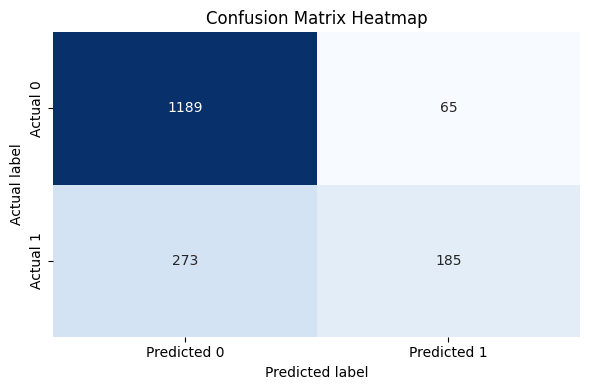

In [4]:
# STEP 4 — Baseline model training and evaluation
# This cell trains a baseline pipeline on engineered features and reports classification results.

# Training the model on correlation engineered features and comparing performance to a baseline model trained on original features (except those dropped due to engineering).
X = pd.get_dummies(df_fe.drop(columns=['Game_ID', 'Is_Winner']), drop_first=False)
y = df_fe['Is_Winner']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)
print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

# Build baseline pipeline
P = Pipeline([
    ('scaler', StandardScaler()),
    ('feat_selection', SelectFromModel(GradientBoostingClassifier(random_state=101))),
    ('model', GradientBoostingClassifier(random_state=101))
])

# Fit baseline model and make predictions
P.fit(X_train, y_train)
print("Model trained")
y_preds = P.predict(X_test)

# Reusable evaluation helper (table + confusion matrix + heatmap)
def model_evaluation(y_test, y_preds):
    report_df = pd.DataFrame(
        classification_report(y_test, y_preds, output_dict=True)
    ).transpose().round(3)
    confusion_df = pd.DataFrame(
        confusion_matrix(y_test, y_preds),
        index=['Actual 0', 'Actual 1'],
        columns=['Predicted 0', 'Predicted 1']
    )

    print("Classification report")
    display(report_df)
    print("Confusion matrix")
    display(confusion_df)

    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_df, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Confusion Matrix Heatmap')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

    return report_df, confusion_df

# Evaluate baseline model
model_report, model_confusion = model_evaluation(y_test, y_preds)

Best tuning configuration (recall-first objective)


,positive_class_weight,threshold,validation_accuracy,validation_precision_class_1,validation_recall_class_1,validation_f1_class_1,tuning_score,feat_selection__threshold,model__learning_rate,model__max_depth,model__n_estimators
0,4.0,0.35,0.582,0.399,0.979,0.567,0.768,median,0.05,3,200


Top tuning results


,positive_class_weight,threshold,validation_accuracy,validation_precision_class_1,validation_recall_class_1,validation_f1_class_1,tuning_score,feat_selection__threshold,model__learning_rate,model__max_depth,model__n_estimators
0,4.0,0.35,0.582,0.399,0.979,0.567,0.768,median,0.05,3,200
1,4.0,0.40,0.587,0.401,0.971,0.568,0.765,median,0.05,3,100
2,4.0,0.35,0.546,0.379,0.984,0.547,0.762,median,0.05,3,100
3,4.0,0.35,0.582,0.398,0.969,0.564,0.762,median,0.10,3,100
4,3.0,0.35,0.592,0.403,0.963,0.568,0.761,median,0.05,3,100
5,4.0,0.35,0.606,0.411,0.955,0.575,0.760,median,0.10,3,200
6,4.0,0.35,0.561,0.386,0.974,0.553,0.759,median,0.10,2,200
7,4.0,0.35,0.542,0.377,0.979,0.544,0.758,median,0.10,2,100
8,4.0,0.35,0.541,0.376,0.979,0.543,0.758,median,0.05,2,200
9,4.0,0.40,0.569,0.390,0.966,0.556,0.757,median,0.10,2,100


Tuned model evaluation on the test set
Classification report


,precision,recall,f1-score,support
0,0.970,0.411,0.578,1254.00
1,0.375,0.965,0.540,458.00
accuracy,0.560,0.560,0.560,0.56
macro avg,0.672,0.688,0.559,1712.00
weighted avg,0.811,0.560,0.568,1712.00


Confusion matrix


,Predicted 0,Predicted 1
Actual 0,516,738
Actual 1,16,442


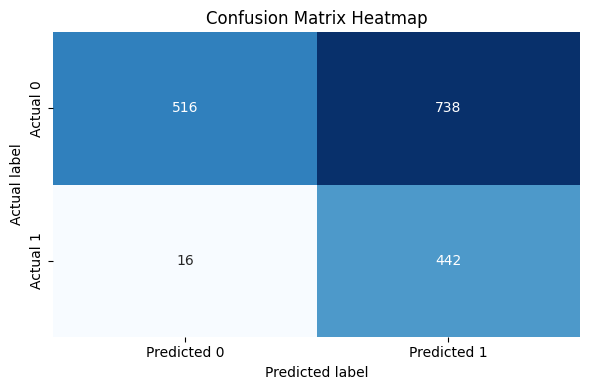

Baseline vs tuned summary


,baseline_accuracy,baseline_recall_class_1,baseline_f1_class_1,baseline_precision_class_1,tuned_accuracy,tuned_recall_class_1,tuned_f1_class_1,tuned_precision_class_1
0,0.803,0.404,0.523,0.74,0.56,0.965,0.54,0.375


In [ ]:
# STEP 5 — Hyperparameter tuning with class-weight and threshold search (balanced constraints)
# This cell improves winner recall while protecting overall accuracy and winner precision.

from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import ParameterGrid

# Create a validation split from the training data for tuning.
X_tune_train, X_val, y_tune_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=101,
    stratify=y_train
)

# Baseline-derived safety floors (to avoid collapsing accuracy/precision)
baseline_acc = float(model_report.loc['accuracy', 'precision']) if 'model_report' in globals() else 0.80
baseline_precision_1 = float(model_report.loc['1', 'precision']) if 'model_report' in globals() else 0.70

min_accuracy = max(0.0, baseline_acc - 0.02)          # allow at most ~2 points drop
min_precision_class_1 = max(0.0, baseline_precision_1 - 0.10)  # allow some precision trade-off

# Candidate search space
param_grid = {
    'feat_selection__threshold': ['median', 'mean'],
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3],
}
positive_class_weights = [1.0, 1.5, 2.0, 2.5, 3.0]

# Include both moderate and conservative thresholds to recover precision/accuracy
threshold_candidates = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75]

best_result = None
best_score = -np.inf
tuning_rows = []

# Grid search over params + class weights + thresholds
for params in ParameterGrid(param_grid):
    for positive_weight in positive_class_weights:
        candidate_model = clone(P)
        candidate_model.set_params(**params)

        tune_sample_weight = np.where(y_tune_train == 1, positive_weight, 1.0)
        candidate_model.fit(
            X_tune_train,
            y_tune_train,
            feat_selection__sample_weight=tune_sample_weight,
            model__sample_weight=tune_sample_weight
        )

        val_probs = candidate_model.predict_proba(X_val)[:, 1]

        for threshold in threshold_candidates:
            val_preds = (val_probs >= threshold).astype(int)
            precision_1 = precision_score(y_val, val_preds, pos_label=1, zero_division=0)
            recall_1 = recall_score(y_val, val_preds, pos_label=1, zero_division=0)
            f1_1 = f1_score(y_val, val_preds, pos_label=1, zero_division=0)
            accuracy = accuracy_score(y_val, val_preds)

            # Constrained ranking:
            # 1) Prefer configs that keep accuracy/precision near baseline.
            # 2) Among feasible configs, maximize winner recall.
            feasible = (accuracy >= min_accuracy) and (precision_1 >= min_precision_class_1)
            acc_gap = max(0.0, min_accuracy - accuracy)
            prec_gap = max(0.0, min_precision_class_1 - precision_1)

            if feasible:
                tuning_score = 1000.0 + (0.70 * recall_1) + (0.20 * f1_1) + (0.10 * accuracy)
            else:
                # Fallback score with strong penalties for violating floors
                penalty = (2.0 * acc_gap) + (2.0 * prec_gap)
                tuning_score = (0.40 * recall_1) + (0.25 * f1_1) + (0.20 * precision_1) + (0.15 * accuracy) - penalty

            row = {
                'feasible': feasible,
                'positive_class_weight': positive_weight,
                'threshold': threshold,
                'validation_accuracy': round(accuracy, 3),
                'validation_precision_class_1': round(precision_1, 3),
                'validation_recall_class_1': round(recall_1, 3),
                'validation_f1_class_1': round(f1_1, 3),
                'tuning_score': round(tuning_score, 3),
                **params,
            }
            tuning_rows.append(row)

            if tuning_score > best_score:
                best_score = tuning_score
                best_result = row.copy()
                best_params = params.copy()
                best_threshold = threshold
                best_positive_weight = positive_weight

# Retrain the tuned model on the full training split.
tuned_model = clone(P)
tuned_model.set_params(**best_params)
full_sample_weight = np.where(y_train == 1, best_positive_weight, 1.0)
tuned_model.fit(
    X_train,
    y_train,
    feat_selection__sample_weight=full_sample_weight,
    model__sample_weight=full_sample_weight
)

# Predict probabilities and apply best threshold
tuned_probs = tuned_model.predict_proba(X_test)[:, 1]
tuned_y_preds = (tuned_probs >= best_threshold).astype(int)

# Rank and show top tuning runs
tuning_results = pd.DataFrame(tuning_rows).sort_values(
    by=['feasible', 'tuning_score', 'validation_recall_class_1', 'validation_f1_class_1'],
    ascending=[False, False, False, False]
).reset_index(drop=True)

print('Constraint floors used in tuning')
print(f"Minimum validation accuracy: {min_accuracy:.3f}")
print(f"Minimum validation precision (class 1): {min_precision_class_1:.3f}")
print('Best tuning configuration (balanced constraints)')
display(pd.DataFrame([best_result]))
print('Top tuning results')
display(tuning_results.head(10))
print('Tuned model evaluation on the test set')
tuned_report, tuned_confusion = model_evaluation(y_test, tuned_y_preds)

# Baseline vs tuned summary table
if 'model_report' in globals():
    baseline_summary = {
        'baseline_accuracy': round(float(model_report.loc['accuracy', 'precision']), 3),
        'baseline_recall_class_1': round(float(model_report.loc['1', 'recall']), 3),
        'baseline_f1_class_1': round(float(model_report.loc['1', 'f1-score']), 3),
        'baseline_precision_class_1': round(float(model_report.loc['1', 'precision']), 3),
    }
    tuned_summary = {
        'tuned_accuracy': round(float(tuned_report.loc['accuracy', 'precision']), 3),
        'tuned_recall_class_1': round(float(tuned_report.loc['1', 'recall']), 3),
        'tuned_f1_class_1': round(float(tuned_report.loc['1', 'f1-score']), 3),
        'tuned_precision_class_1': round(float(tuned_report.loc['1', 'precision']), 3),
    }
    print('Baseline vs tuned summary')
    display(pd.DataFrame([baseline_summary | tuned_summary]))

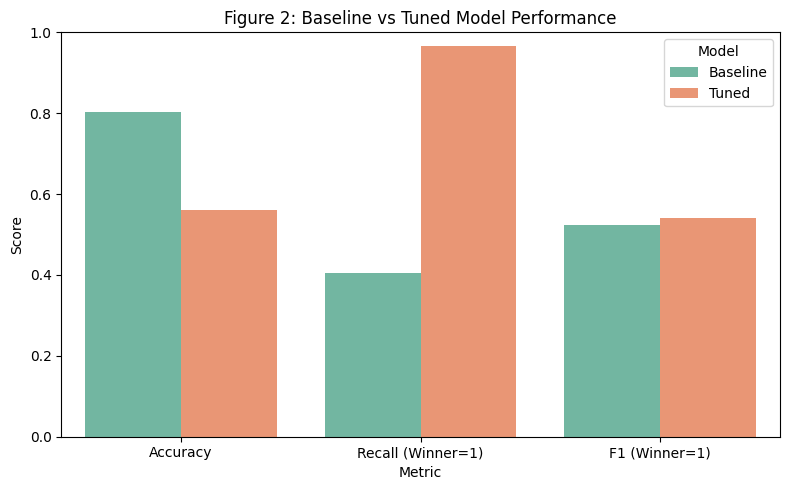

Saved tuned pipeline artifact to: /home/chizoalban2003/ludomaniac/jupyter_notebooks/artifacts/tuned_ludo_pipeline.pkl


In [9]:
# STEP 6 — Compare baseline vs tuned model and save tuned artifact
# This cell plots key metrics and persists the tuned pipeline for later inference.

# Plot baseline vs tuned metrics, then save the tuned pipeline for future use.
import joblib

# Build comparison table (recompute if summaries are not in memory)
if 'baseline_summary' not in globals() and 'model_report' in globals():
    baseline_summary = {
        'baseline_accuracy': round(float(model_report.loc['accuracy', 'precision']), 3),
        'baseline_recall_class_1': round(float(model_report.loc['1', 'recall']), 3),
        'baseline_f1_class_1': round(float(model_report.loc['1', 'f1-score']), 3),
    }

if 'tuned_summary' not in globals() and 'tuned_report' in globals():
    tuned_summary = {
        'tuned_accuracy': round(float(tuned_report.loc['accuracy', 'precision']), 3),
        'tuned_recall_class_1': round(float(tuned_report.loc['1', 'recall']), 3),
        'tuned_f1_class_1': round(float(tuned_report.loc['1', 'f1-score']), 3),
    }

# Create side-by-side comparison dataframe
comparison_df = pd.DataFrame([
    {
        'metric': 'Accuracy',
        'Baseline': baseline_summary['baseline_accuracy'],
        'Tuned': tuned_summary['tuned_accuracy'],
    },
    {
        'metric': 'Recall (Winner=1)',
        'Baseline': baseline_summary['baseline_recall_class_1'],
        'Tuned': tuned_summary['tuned_recall_class_1'],
    },
    {
        'metric': 'F1 (Winner=1)',
        'Baseline': baseline_summary['baseline_f1_class_1'],
        'Tuned': tuned_summary['tuned_f1_class_1'],
    },
])

comparison_long = comparison_df.melt(id_vars='metric', var_name='Model', value_name='Score')

# Plot baseline vs tuned scores
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_long, x='metric', y='Score', hue='Model', palette='Set2')
plt.ylim(0, 1)
plt.title('Figure 2: Baseline vs Tuned Model Performance')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.tight_layout()
plt.show()

# Save tuned pipeline + threshold metadata
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

tuned_artifact = {
    'pipeline': tuned_model,
    'decision_threshold': best_threshold,
    'positive_class_weight': best_positive_weight,
    'best_params': best_params,
    'feature_columns': X_train.columns.tolist(),
}

model_path = artifacts_dir / 'tuned_ludo_pipeline.pkl'
joblib.dump(tuned_artifact, model_path)
print(f"Saved tuned pipeline artifact to: {model_path.resolve()}")

Top 10 feature importances from the tuned model


,feature,importance
0,eng_weak_neg_combo__token_moved__tokens_home,0.300895
1,eng_strong_neg_mul__turn__tokens_home,0.283377
2,Player_Red,0.132454
3,eng_weak_neg_combo__turn__captured_opponent,0.071775
4,eng_weak_neg_combo__token_moved__position_before,0.044630
5,eng_strong_pos_div__turn__tokens_finished,0.035883
6,Player_Blue,0.035345
7,eng_weak_neg_combo__token_moved__captured_oppo...,0.020107
8,eng_weak_neg_combo__position_after__tokens_fin...,0.017454
9,eng_weak_neg_combo__tokens_finished__captured_...,0.016437


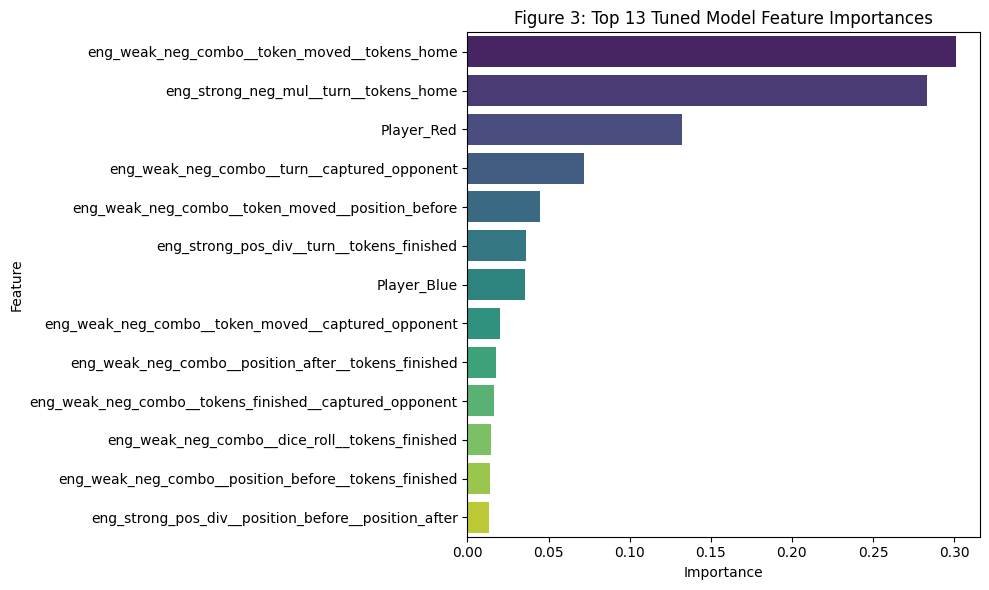

In [7]:
# STEP 7 — Feature importance view from the tuned pipeline
# This cell aligns model importances with selected features and plots the top contributors.

# Feature importance from the tuned model
if hasattr(tuned_model.named_steps['model'], 'feature_importances_'):
    importances = tuned_model.named_steps['model'].feature_importances_

    # Map importances to the feature subset kept by SelectFromModel
    support_mask = tuned_model.named_steps['feat_selection'].get_support()
    selected_feature_names = X_train.columns[support_mask]

    importance_df = pd.DataFrame({
        'feature': selected_feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False).reset_index(drop=True)

    print("Top 10 feature importances from the tuned model")
    display(importance_df.head(10))

    # Plot top features for easier interpretation
    top_n = min(15, len(importance_df))
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=importance_df.head(top_n),
        x='importance',
        y='feature',
        hue='feature',
        palette='viridis',
        legend=False
    )
    plt.title(f'Figure 3: Top {top_n} Tuned Model Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("The tuned model does not expose feature importances.")